In [13]:
import cv2

video_path = "interview.mp4"

cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print("FPS:", fps)
print("Total Frames:", frame_count)

FPS: 50.0
Total Frames: 53902


FPS: 50.0
Total Frames: 53902


Eye Contact: 100%|██████████| 53902/53902 [09:29<00:00, 94.58it/s]   


Saved eye_contact.csv
   frame  eye_contact
0      5          1.0
1     10          1.0
2     15          1.0
3     20          1.0
4     25          1.0


Posture: 100%|██████████| 53902/53902 [08:54<00:00, 100.89it/s] 


Saved posture.csv
   frame  posture_score
0      5       0.963889
1     10       0.975926
2     15       0.968519
3     20       0.983333
4     25       0.987963


Movement: 100%|██████████| 53901/53901 [14:55<00:00, 60.22it/s]   


Saved body_movement.csv
   frame  movement_score
0      5       1072354.0
1     10        977276.0
2     15        885593.0
3     20        800453.0
4     25        621997.0


Expression: 100%|██████████| 53902/53902 [16:50<00:00, 53.32it/s]   


Saved facial_expression.csv
   frame expression
0      5    neutral
1     10    neutral
2     15    neutral
3     20    neutral
4     25    neutral
   frame  movement_score expression  eye_contact  posture_score  \
0      5       1072354.0    neutral          1.0       0.963889   
1     10        977276.0    neutral          1.0       0.975926   
2     15        885593.0    neutral          1.0       0.968519   
3     20        800453.0    neutral          1.0       0.983333   
4     25        621997.0    neutral          1.0       0.987963   

   movement_norm  expression_score  body_language_score  \
0       0.115536               0.7            82.454791   
1       0.105180               0.7            82.762768   
2       0.095194               0.7            81.918870   
3       0.085920               0.7            82.436813   
4       0.066482               0.7            81.937076   

   facial_expression_score  eye_contact_score  confidence_score  overall_score  
0            

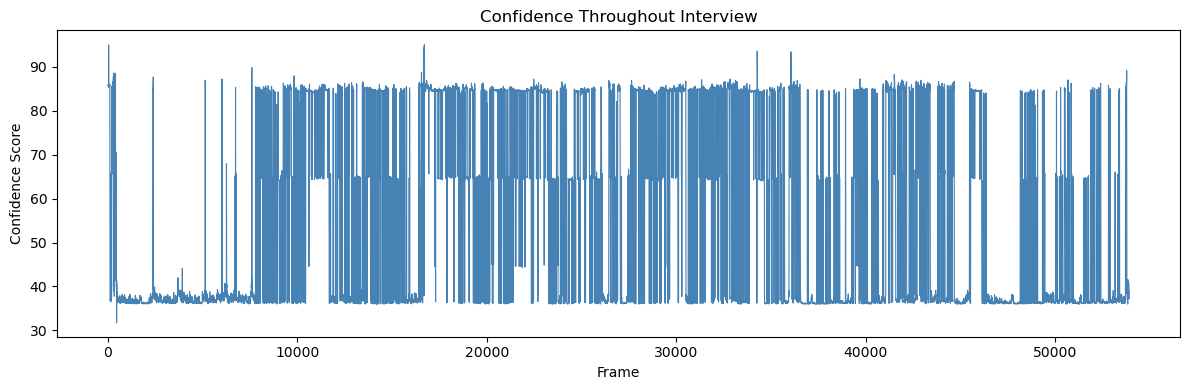

Plot saved as confidence_plot.png


In [27]:
import cv2

video_path = "interview.mp4"
cap = cv2.VideoCapture(video_path)
fps        = cap.get(cv2.CAP_PROP_FPS)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
cap.release()
print("FPS:", fps)
print("Total Frames:", frame_count)


import numpy as np
import pandas as pd
from tqdm import tqdm

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
eye_cascade  = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_eye.xml")

cap = cv2.VideoCapture(video_path)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

eye_data  = []
frame_num = 0

for _ in tqdm(range(total_frames), desc="Eye Contact"):
    ret, frame = cap.read()
    if not ret:
        break

    frame_num += 1
    if frame_num % 5 != 0:
        continue

    gray  = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5, minSize=(80, 80))

    eye_contact = 0.0
    for (x, y, w, h) in faces:
        roi = gray[y:y + h, x:x + w]
        eyes = eye_cascade.detectMultiScale(roi, 1.1, 10)
        # Both eyes visible = looking at camera
        if len(eyes) >= 2:
            eye_contact = 1.0
        elif len(eyes) == 1:
            eye_contact = 0.5
        break  # first face only

    eye_data.append({"frame": frame_num, "eye_contact": eye_contact})

cap.release()

eye_df = pd.DataFrame(eye_data)
eye_df.to_csv("eye_contact.csv", index=False)
print("Saved eye_contact.csv")
print(eye_df.head())

import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

cap = cv2.VideoCapture(video_path)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

posture_data = []
frame_num    = 0

for _ in tqdm(range(total_frames), desc="Posture"):
    ret, frame = cap.read()
    if not ret:
        break

    frame_num += 1
    if frame_num % 5 != 0:
        continue

    gray  = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5, minSize=(80, 80))

    posture_score = 0.5  # neutral default
    for (x, y, w, h) in faces:
        # Face centre Y relative to frame height
        face_center_y = (y + h / 2) / frame_height
        # Good posture: face in upper 40% of frame → score near 1.0
        # Slouching: face slides lower → score drops
        posture_score = max(0.0, min(1.0, 1.0 - (face_center_y - 0.25) * 2))
        break

    posture_data.append({"frame": frame_num, "posture_score": posture_score})

cap.release()

posture_df = pd.DataFrame(posture_data)
posture_df.to_csv("posture.csv", index=False)
print("Saved posture.csv")
print(posture_df.head())

import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm

cap = cv2.VideoCapture(video_path)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

ret, prev_frame = cap.read()
prev_gray = cv2.cvtColor(prev_frame, cv2.COLOR_BGR2GRAY)

movement_data = []
frame_num     = 1

for _ in tqdm(range(total_frames - 1), desc="Movement"):
    ret, frame = cap.read()
    if not ret:
        break

    frame_num += 1
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    if frame_num % 5 == 0:
        diff = cv2.absdiff(prev_gray, gray)
        movement_score = float(np.sum(diff))
        movement_data.append({"frame": frame_num, "movement_score": movement_score})

    prev_gray = gray

cap.release()

movement_df = pd.DataFrame(movement_data)
movement_df.to_csv("body_movement.csv", index=False)
print("Saved body_movement.csv")
print(movement_df.head())

import cv2
import pandas as pd
from tqdm import tqdm

face_cascade  = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
smile_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_smile.xml")

cap = cv2.VideoCapture(video_path)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

expression_data = []
frame_num       = 0

for _ in tqdm(range(total_frames), desc="Expression"):
    ret, frame = cap.read()
    if not ret:
        break

    frame_num += 1
    if frame_num % 5 != 0:
        continue

    gray  = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5, minSize=(80, 80))

    expression = "neutral"
    for (x, y, w, h) in faces:
        roi_gray = gray[y:y + h, x:x + w]
        smiles   = smile_cascade.detectMultiScale(roi_gray, 1.7, 20)
        if len(smiles) > 0:
            expression = "smile"
        break

    expression_data.append({"frame": frame_num, "expression": expression})

cap.release()

expression_df = pd.DataFrame(expression_data)
expression_df.to_csv("facial_expression.csv", index=False)
print("Saved facial_expression.csv")
print(expression_df.head())


import pandas as pd
import numpy as np

movement   = pd.read_csv("body_movement.csv")
expression = pd.read_csv("facial_expression.csv")
eye        = pd.read_csv("eye_contact.csv")
posture    = pd.read_csv("posture.csv")

df = movement.merge(expression, on="frame", how="outer")
df = df.merge(eye,     on="frame", how="outer")
df = df.merge(posture, on="frame", how="outer")
df = df.ffill().bfill()

# Normalize movement 0-1
mov_range = df["movement_score"].max() - df["movement_score"].min()
df["movement_norm"] = (df["movement_score"] - df["movement_score"].min()) / (mov_range + 1e-9)

# Expression → numeric
expression_map = {"smile": 1.0, "neutral": 0.7, "tense": 0.4}
df["expression_score"] = df["expression"].map(expression_map).fillna(0.7)

# Scale to 100
df["body_language_score"]     = ((1 - abs(df["movement_norm"] - 0.5)) * 0.4 + df["posture_score"] * 0.6) * 100
df["facial_expression_score"] = df["expression_score"] * 100
df["eye_contact_score"]       = df["eye_contact"] * 100

df["confidence_score"] = (
    df["eye_contact_score"]       * 0.4 +
    df["facial_expression_score"] * 0.3 +
    df["body_language_score"]     * 0.3
)

df["overall_score"] = (
    df["confidence_score"]        * 0.5 +
    df["body_language_score"]     * 0.3 +
    df["facial_expression_score"] * 0.2
)

print(df.head())

final_scores = {
    "Body Language":           round(df["body_language_score"].mean(), 2),
    "Facial Expression":       round(df["facial_expression_score"].mean(), 2),
    "Eye Contact":             round(df["eye_contact_score"].mean(), 2),
    "Confidence":              round(df["confidence_score"].mean(), 2),
    "Overall Interview Score": round(df["overall_score"].mean(), 2),
}

for k, v in final_scores.items():
    print(f"{k}: {v}")

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(df["frame"], df["confidence_score"], linewidth=0.8, color="steelblue")
plt.xlabel("Frame")
plt.ylabel("Confidence Score")
plt.title("Confidence Throughout Interview")
plt.tight_layout()
plt.savefig("confidence_plot.png", dpi=150)
plt.show()
print("Plot saved as confidence_plot.png")